In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import viridis, jet, RdYlGn_r
from netCDF4 import Dataset as NetCDFFile
import netCDF4 as nc

import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf

import os

In [2]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

def unnormalise(data_sr, data_lr):
    max = np.max(data_lr)
    min = np.min(data_lr)
    data_sr = data_sr * (max - min) + min
    return data_sr

## Past downstream task test (PS detection)

In [5]:
file = NetCDFFile('../RDS/OCO-2/oco2_GEOS_L3CO2_day_20200511_B10206Ar.nc4')
data = np.squeeze(file.variables['XCO2'][:])
lat = np.squeeze(file.variables['lat'][:])
lon = np.squeeze(file.variables['lon'][:])

lon_reshaped = np.reshape(lon, (1, 576))
lat_reshaped = np.reshape(lat, (361, 1))

new_lon, new_lat = np.broadcast_arrays(lon_reshaped, lat_reshaped)
new_lon = new_lon.flatten()
new_lat = new_lat.flatten()

In [6]:
lonE = 14
lonW = -6
latS = 42
latN = 60

print(0.5*31, 0.625*31)

extents = (lonW, lonW+19.375, latS, latS+15.5)

15.5 19.375


In [7]:
lonE_sr = find_nearest(lon, lonW+20)
lonW_sr = find_nearest(lon, lonW)
latS_sr = find_nearest(lat, latS)
latN_sr = find_nearest(lat, latS+16)

print(lonE_sr, lonW_sr, latS_sr, latN_sr)

310 278 264 296


In [6]:
europe_lr = np.load('Input/XCO2/europe_lr_2020.npy')
europe_lr = europe_lr*1e6
# europe_lr = data[latS_sr:latN_sr, lonW_sr:lonE_sr]
# np.save('europe_lr.npy', np.asarray(europe_lr))

In [7]:
print(np.shape(europe_lr))

(32, 32)


In [8]:
europe_sr = np.load('Result/XCO2/europe_lr_2020.npy')
europe_sr = unnormalise(europe_sr, europe_lr)


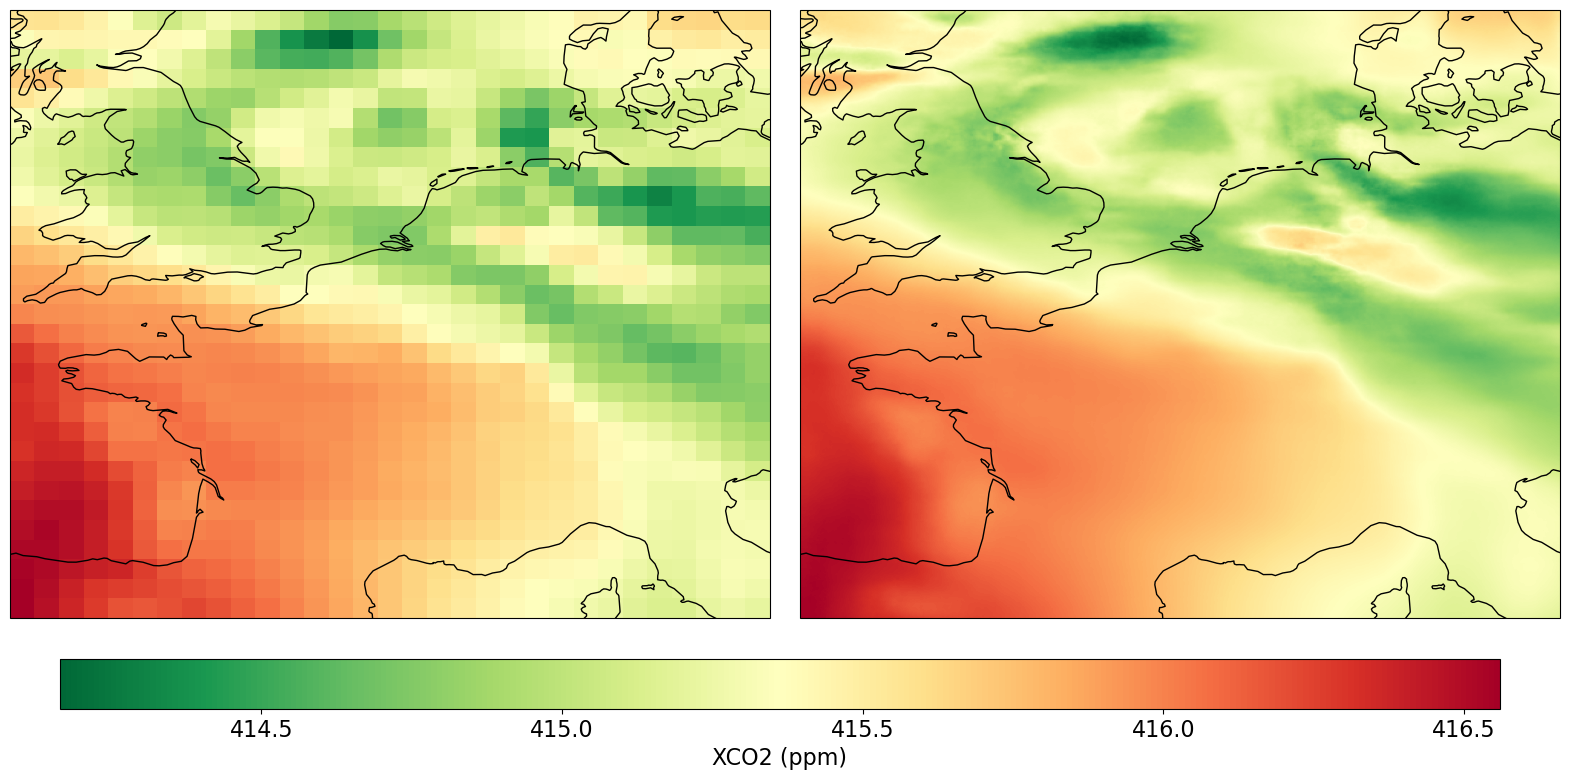

In [9]:
fig = plt.figure(figsize=(20, 10))
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.coastlines()
im = ax1.imshow(europe_lr[:-1,:-1], extent=extents, cmap=RdYlGn_r, vmin=np.min(europe_lr[:-1,:-1]), vmax=np.max(europe_lr[:-1,:-1]))
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.coastlines()
ax2.imshow(europe_sr[:-16,:-16], extent=extents, cmap=RdYlGn_r)
fig.subplots_adjust(wspace=0.04)
cbar_ax = fig.add_axes([0.15, 0.10, 0.72, 0.05])
cbar = fig.colorbar(im, orientation='horizontal', cax=cbar_ax)
cbar.ax.tick_params(labelsize=16)
cbar.set_label(label='XCO2 (ppm)', size=16)

-2.322456566616893e-06 2.0564802980516106e-06


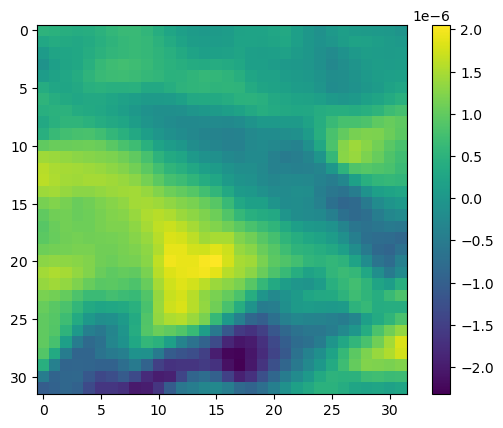

In [37]:
file_test = np.load('Input/XCO2/0_lr.npy')
file_lr = np.expand_dims(file_test, axis=0)
print(np.min(file_test), np.max(file_test))
plt.imshow(file_test)
plt.colorbar()


In [3]:
def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

In [4]:
def unnormalize(array_sr, array_lr):
    for i in range(len(array_sr)):
        array_sr[i] = normalize(array_sr[i])
        min = np.min(array_lr[i])
        max = np.max(array_lr[i])
        array_sr[i] = (array_sr[i] * (max - min)) + min
    return array_sr

-3.0314077e-06 7.237941e-07


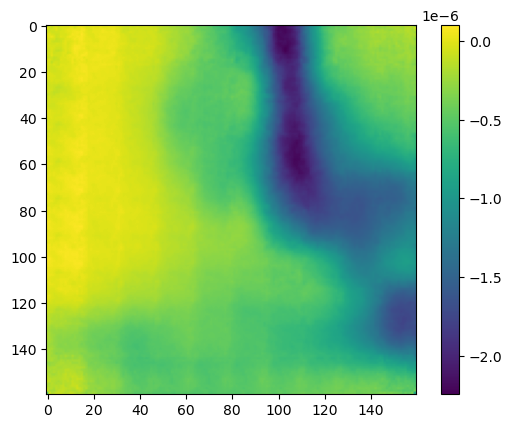

In [7]:
file_test = np.load('../../RDS/ephemeral/difference_xco2_test/sr/diff/0_lr.npy')
# file_test = np.transpose(file_test, (0, 2, 1))
file_test = unnormalize(file_test, lr)
print(np.min(file_test[0]), np.max(file_test[0]))
plt.imshow(file_test[1])
plt.colorbar()


(313, 10, 10)
-3.0314076866488904e-06 7.237940735648775e-07


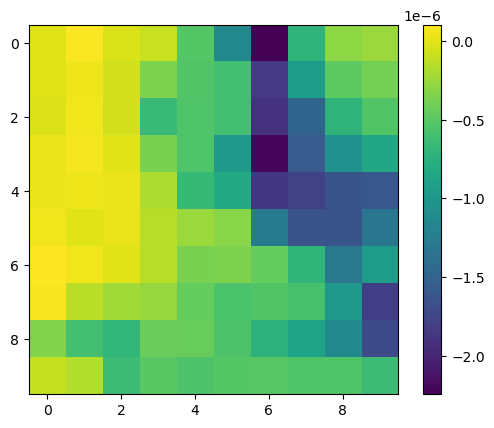

In [6]:
file_test = np.load('../../RDS/ephemeral/difference_xco2_test/lr/diff/0_lr.npy')
# print(np.min(file_test[0]))
print(file_test.shape)
print(np.min(file_test[0]), np.max(file_test[0]))
lr = file_test
plt.imshow(file_test[1])
plt.colorbar()


-2.2608513e-06 2.1352234e-06


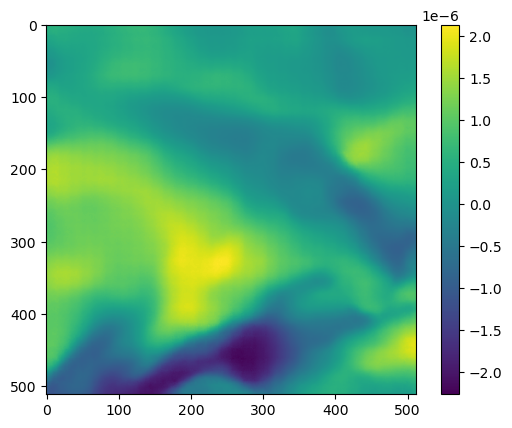

In [36]:
file_test = np.load('../../RDS/dbpn/DBPN_2/Result/XCO2/0_lr.npy')
file_test = unnormalize(np.expand_dims(file_test, axis=0), file_lr)
print(np.min(file_test), np.max(file_test))
plt.imshow(file_test[0])
plt.colorbar()

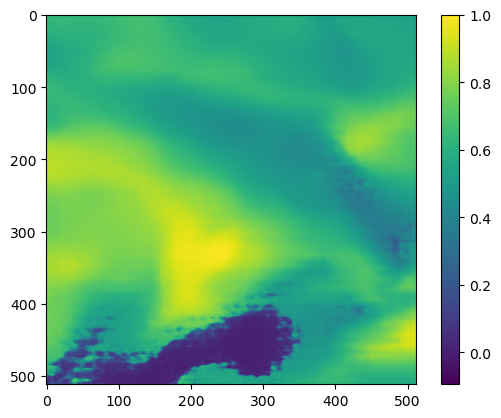

In [4]:
file_test = np.load('Result/XCO2/0_lr_old.npy')
plt.imshow(file_test)
plt.colorbar()

array([0., 1.])

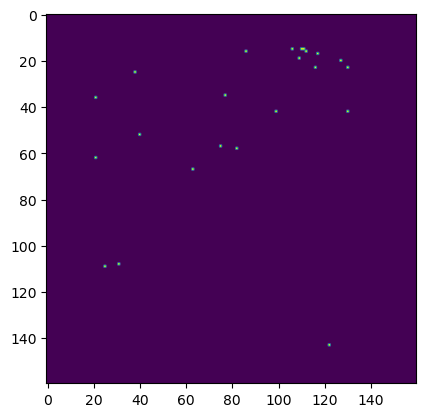

In [2]:
label_sr = np.load('../../RDS/ephemeral/difference_xco2_train/sr/labels/0_sr.npy')
plt.imshow(label_sr)

np.unique(label_sr)

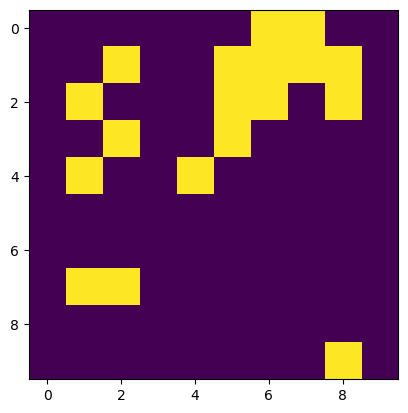

In [3]:
label_lr = np.load('../../RDS/ephemeral/difference_xco2_train/lr/labels/0_lr.npy')
plt.imshow(label_lr)

##  Bicubic interpolation

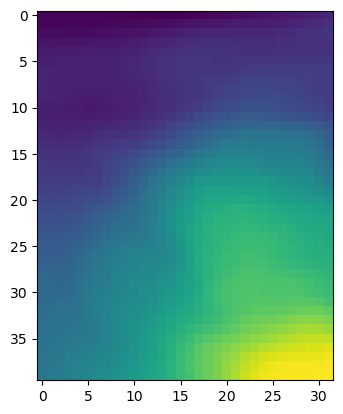

In [154]:
test = np.load('../../RDS/OCO-2/centered_arrays/ae20120522_20181031_20150103_lr.npy')
plt.imshow(test)

In [14]:
from scipy.interpolate import RegularGridInterpolator

In [37]:
europe_lr.shape

(32, 32)

In [15]:
x  = np.arange(0, 32)
y  = np.arange(0, 32)
europe_bicubic = RegularGridInterpolator((x, y), europe_lr, method='cubic')

In [16]:
# best_lat = 8
# best_lon = 10
x_sr = np.arange(0, 31, 1/16)
y_sr = np.arange(0, 31, 1/16)
xv, yv = np.meshgrid(x_sr, y_sr)
xv = xv.flatten()
yv = yv.flatten()
values = np.concatenate((xv[:, np.newaxis], yv[:, np.newaxis]), axis=1)
# values = np.array([best_lat, best_lon])
bic_europe = europe_bicubic(values)
print(bic_europe.shape)
# bic_europe = np.reshape(bic_europe, (16*15, 16*19))
# print(bic_europe)
# bic_europe = np.reshape(bic_europe, (3, 3))
# plt.imshow(bic_europe)

(246016,)


In [17]:
bic_europe = np.reshape(bic_europe, (16*31, 16*31))
bic_europe = np.transpose(bic_europe)

# plt.imshow(bic_europe)

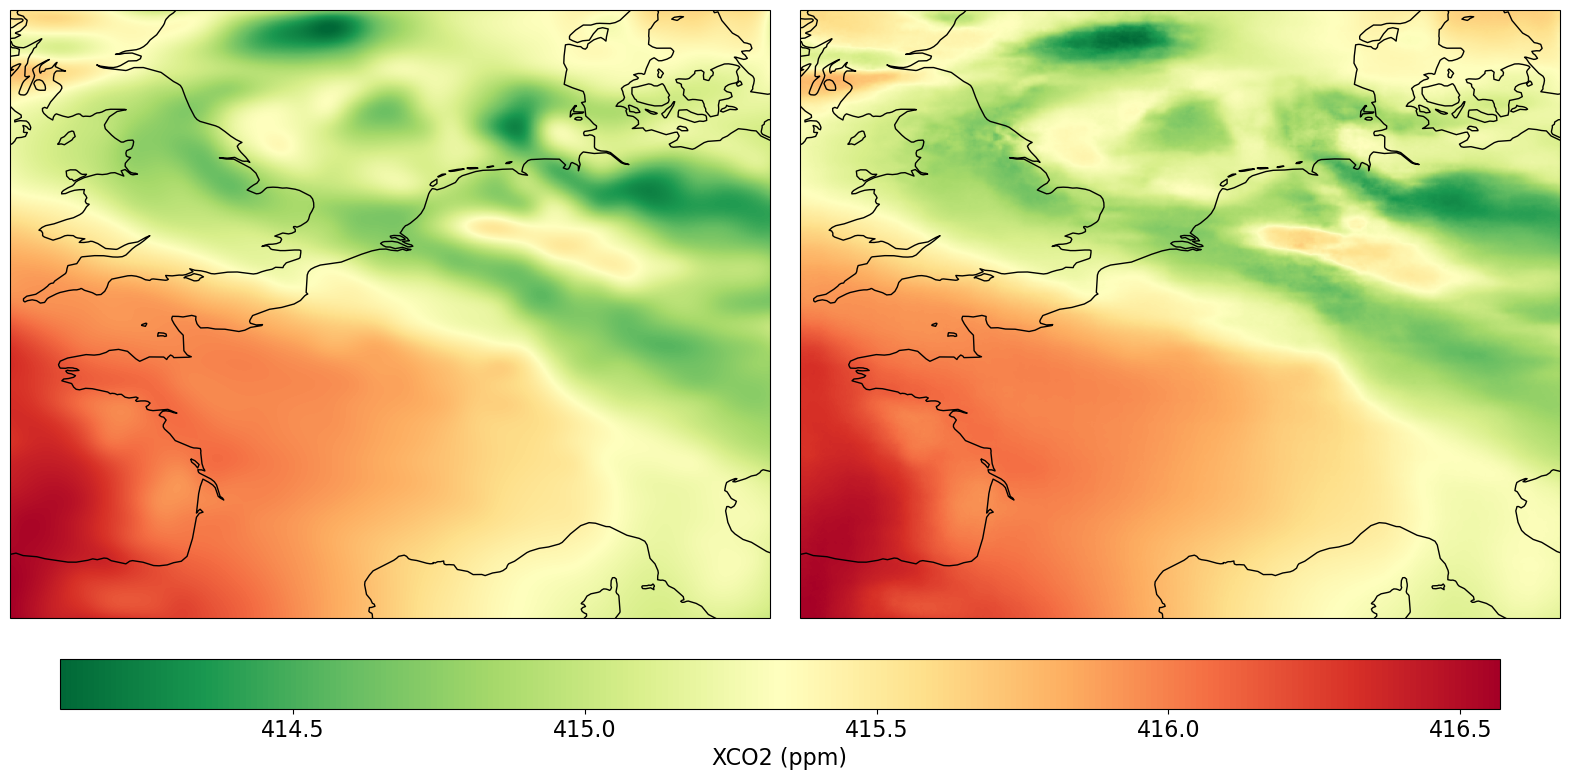

In [38]:
fig = plt.figure(figsize=(20, 10))
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.coastlines()
plt.imshow(bic_europe,extent=extents, cmap=RdYlGn_r, vmin=np.min(europe_lr[:-1,:-1]), vmax=np.max(europe_lr[:-1,:-1]))
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.coastlines()
im = ax2.imshow(europe_sr[:-16,:-16], extent=extents, cmap=RdYlGn_r)
fig.subplots_adjust(wspace=0.04)
cbar_ax = fig.add_axes([0.15, 0.10, 0.72, 0.05])
cbar = fig.colorbar(im, orientation='horizontal', cax=cbar_ax)
cbar.ax.tick_params(labelsize=16)
cbar.set_label(label='XCO2 (ppm)', size=16)

In [10]:
fusion_file = NetCDFFile('../../RDS/data_fusion/2020/2020-05-11.nc')
xco2 = np.asarray(fusion_file.variables['XCO2'][:])
Lat = np.asarray(fusion_file.variables['Lat'][:])
Lon = np.asarray(fusion_file.variables['Lon'][:])

lonE_f = find_nearest(Lon, lonW+20)
lonW_f = find_nearest(Lon, lonW)
latS_f = find_nearest(Lat, latS)
latN_f = find_nearest(Lat, latS+16)

print(lonE_f, lonW_f, latS_f, latN_f)

776 696 528 592


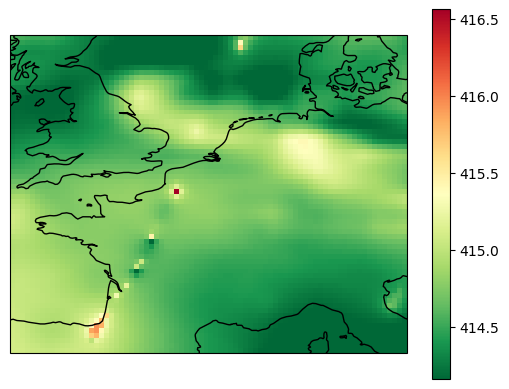

In [11]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()
fus_europe = xco2[latS_f:latN_f, lonW_f:lonE_f]
plt.imshow(fus_europe, extent=extents, cmap=RdYlGn_r, vmin=np.min(europe_lr[:-1,:-1]), vmax=np.max(europe_lr[:-1,:-1]))
plt.colorbar()

In [12]:
minimum = min(np.min(europe_lr[:-1,:-1]), np.min(fus_europe))
maximum = max(np.max(europe_lr[:-1,:-1]), np.max(fus_europe))

print(minimum, maximum)

413.123 416.94464


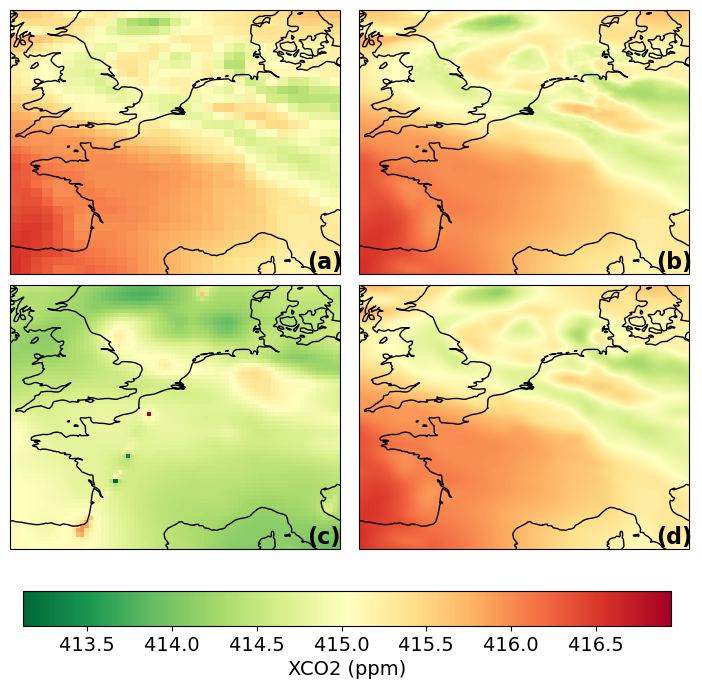

In [18]:
# sns.set()
subfigure_labels = ['(a)', '(b)', '(c)', '(d)']
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
ax1.text(0.9, 0, subfigure_labels[0], transform=ax1.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')
ax1.coastlines()
im = ax1.imshow(europe_lr[:-1,:-1], extent=extents, cmap=RdYlGn_r, vmin=minimum, vmax=maximum)
ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
ax2.text(0.9, 0, subfigure_labels[1], transform=ax2.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')
ax2.coastlines()
ax2.imshow(europe_sr[:-16,:-16], extent=extents, cmap=RdYlGn_r, vmin=minimum, vmax=maximum)
ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
ax3.text(0.9, 0, subfigure_labels[2], transform=ax3.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')
ax3.coastlines()
ax3.imshow(fus_europe, extent=extents, cmap=RdYlGn_r, vmin=minimum, vmax=maximum)
ax4 = fig.add_subplot(2, 2, 4, projection=ccrs.PlateCarree())
ax4.text(0.9, 0, subfigure_labels[3], transform=ax4.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')
ax4.coastlines()
ax4.imshow(bic_europe, extent=extents, cmap=RdYlGn_r, vmin=minimum, vmax=maximum)
fig.subplots_adjust(wspace=0, hspace=0.04)
cbar_ax = fig.add_axes([0.15, 0.0, 0.72, 0.05])
cbar = fig.colorbar(im, orientation='horizontal', cax=cbar_ax)
cbar.ax.tick_params(labelsize=14)
cbar.set_label(label='XCO2 (ppm)', size=14)
plt.s

## Land Surface Temperature data distribution VS CO2 data distribution

In [ ]:
def normalize_array(data):
    vmax = np.amax(data)
    vmin = np.min(data)
    range_data = vmax - vmin
    
    normalized_data = (data - vmin)/range_data
    
    return normalized_data

def random_window(array, size=32):
    # print(array.shape)
    x = np.random.randint(0, array.shape[0]-size)
    y = np.random.randint(0, array.shape[1]-size)
    
    return array[x:x+size, y:y+size]

north_america_box = -135,10,-65.0,60
europe_box = -10, 40, 35, 70
africa_box = -20, -35, 50, 40
asia_box = 40, 0, 150, 70
south_america_box = -80, -50, -40, 10
oceania_box = 115, -40, 155, -10

def sample_within_coordinates(array, coordinates, lon, lat):
    lonW, latS, lonE, latN = coordinates
    lonW = find_nearest(lon, lonW)
    lonE = find_nearest(lon, lonE)
    latS = find_nearest(lat, latS)
    latN = find_nearest(lat, latN)

    if latS > latN:
        return random_window(array[latN:latS, lonW:lonE])
    else:
        return random_window(array[latS:latN, lonW:lonE])

def bin_values(array, bins=11):
    binned_array = np.digitize(array, np.linspace(0, 1, bins))
    
    return binned_array

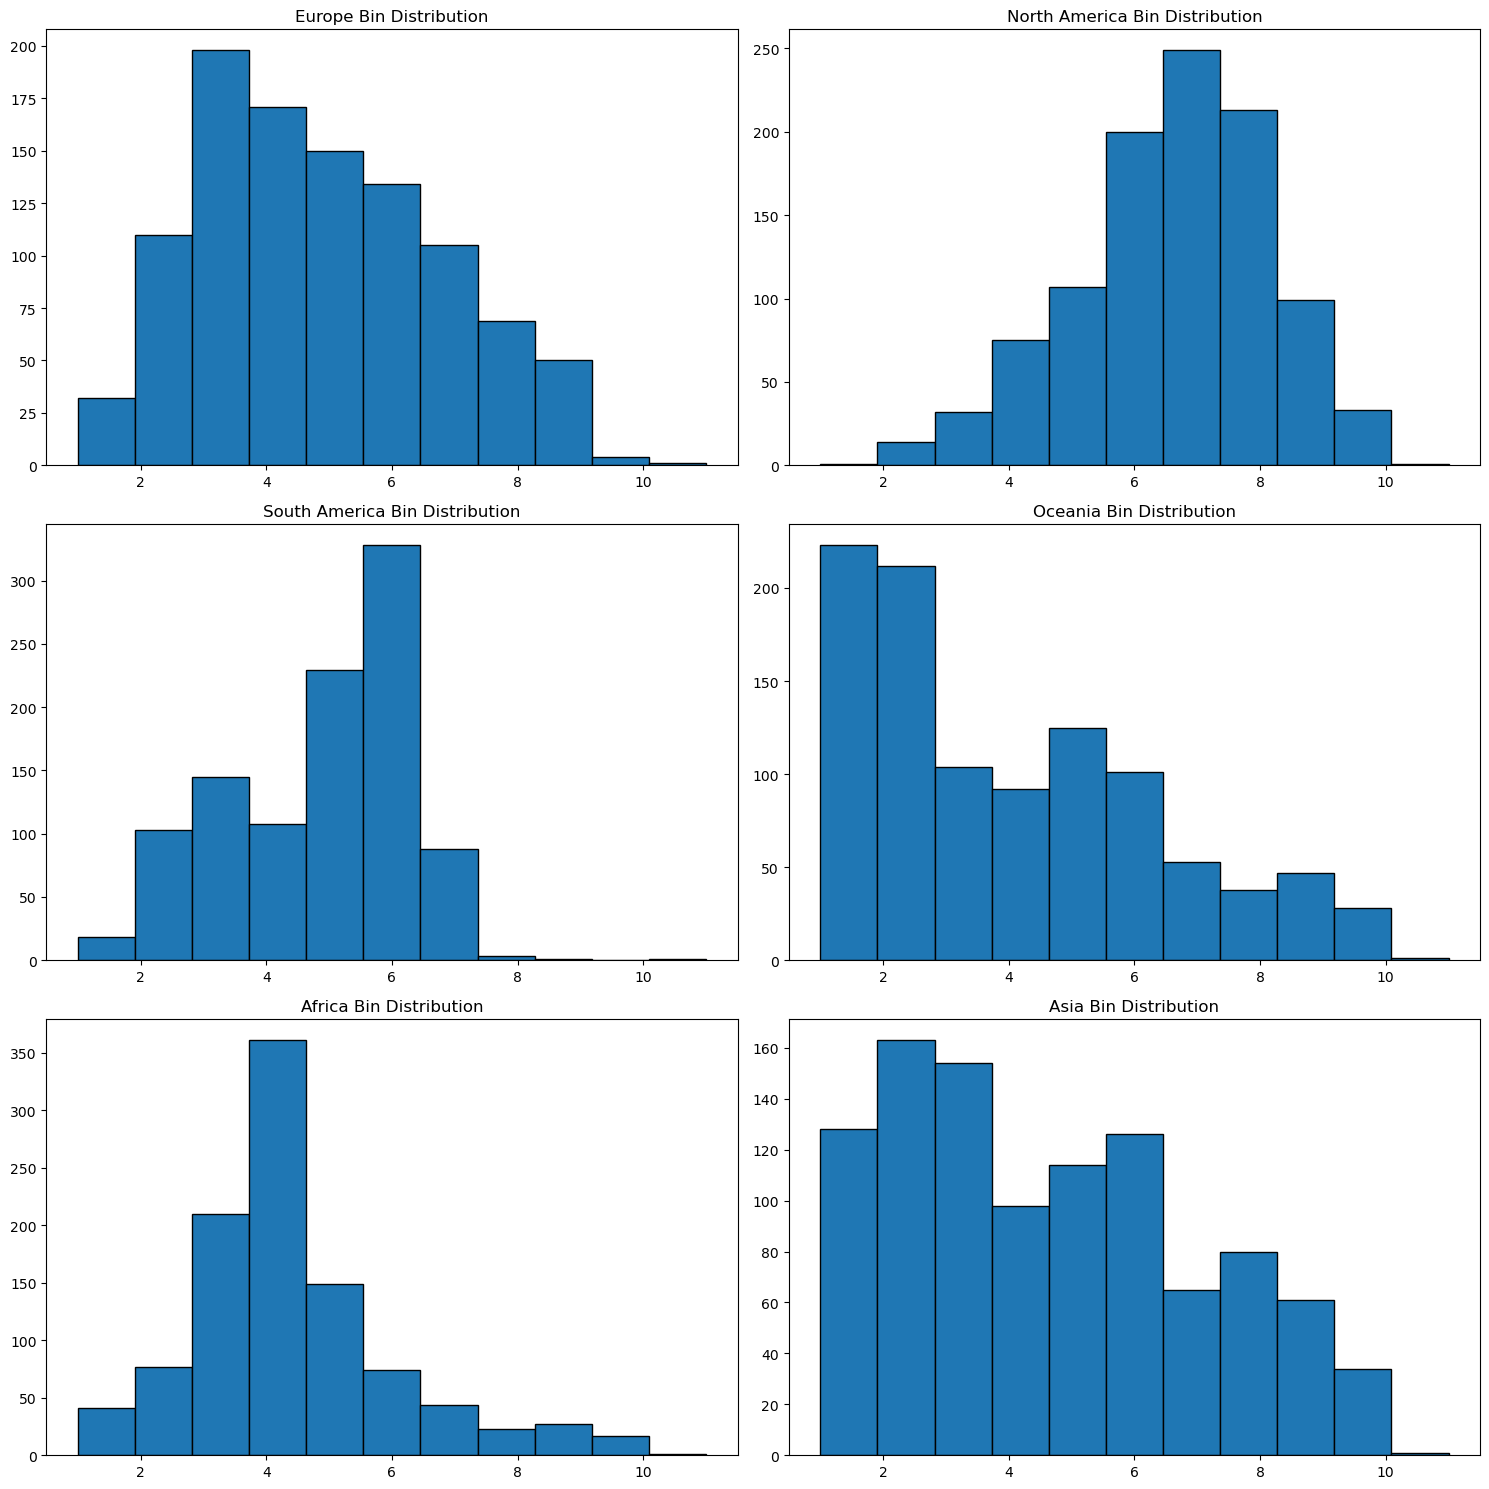

In [4]:
file = xr.open_dataset('../Point_source_detection/data/OCO-2/oco2_GEOS_L3CO2_day_20150101_B10206Ar.nc4')
xco2 = file['XCO2'][0,:,:]
lon = file['lon']
lat = file['lat']


fig, axs = plt.subplots(3, 2, figsize=(15, 15))

regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

for ax, (region_name, region_box) in zip(axs.flatten(), regions.items()):
    region_win = sample_within_coordinates(xco2, region_box, lon, lat)
    norm_region_win = normalize_array(region_win)
    bins_region = bin_values(norm_region_win)
    ax.hist(bins_region.flatten(), bins=11, edgecolor='black')
    ax.set_title(f'{region_name} Bin Distribution')

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


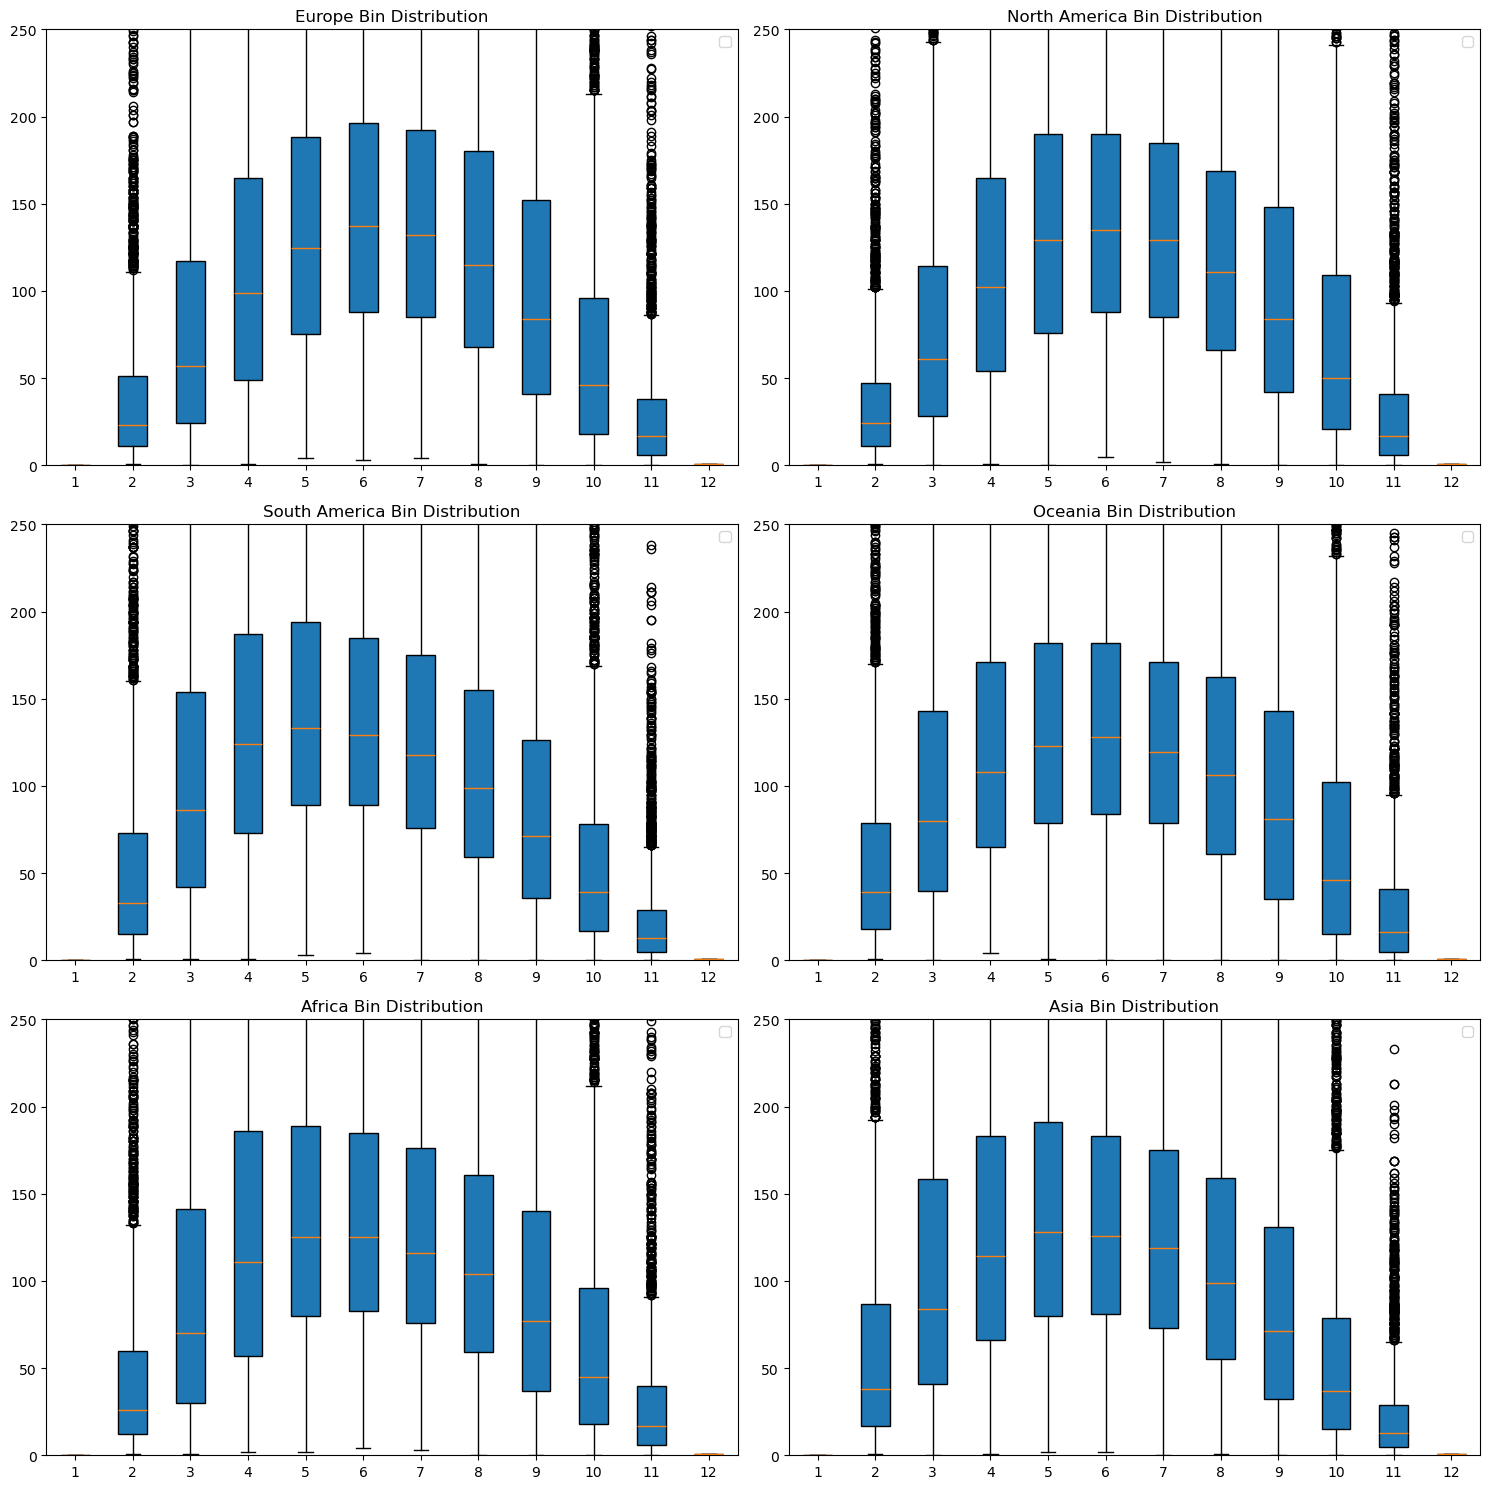

In [ ]:
import json

# file = xr.open_dataset('../Point_source_detection/data/OCO-2/oco2_GEOS_L3CO2_day_20150101_B10206Ar.nc4')
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

region_bins = {region: [] for region in regions}

for filename in os.listdir('../Point_source_detection/data/OCO-2/'):
    file = xr.open_dataset('../Point_source_detection/data/OCO-2/'+filename)
    xco2 = file['XCO2'][0,:,:]
    lon = file['lon']
    lat = file['lat']

    for region_name, region_box in regions.items():
        region_win = sample_within_coordinates(xco2, region_box, lon, lat)
        norm_region_win = normalize_array(region_win)
        bins_region = bin_values(norm_region_win)
        region_card = np.bincount(bins_region.flatten())
        region_bins[region_name].append(region_card)

for ax, (region_name, bins_list) in zip(axs.flatten(), region_bins.items()):
    ax.boxplot(np.asarray(bins_list), patch_artist=True)
    ax.set_ylim(0, 250)
    ax.set_title(f'{region_name} Bin Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


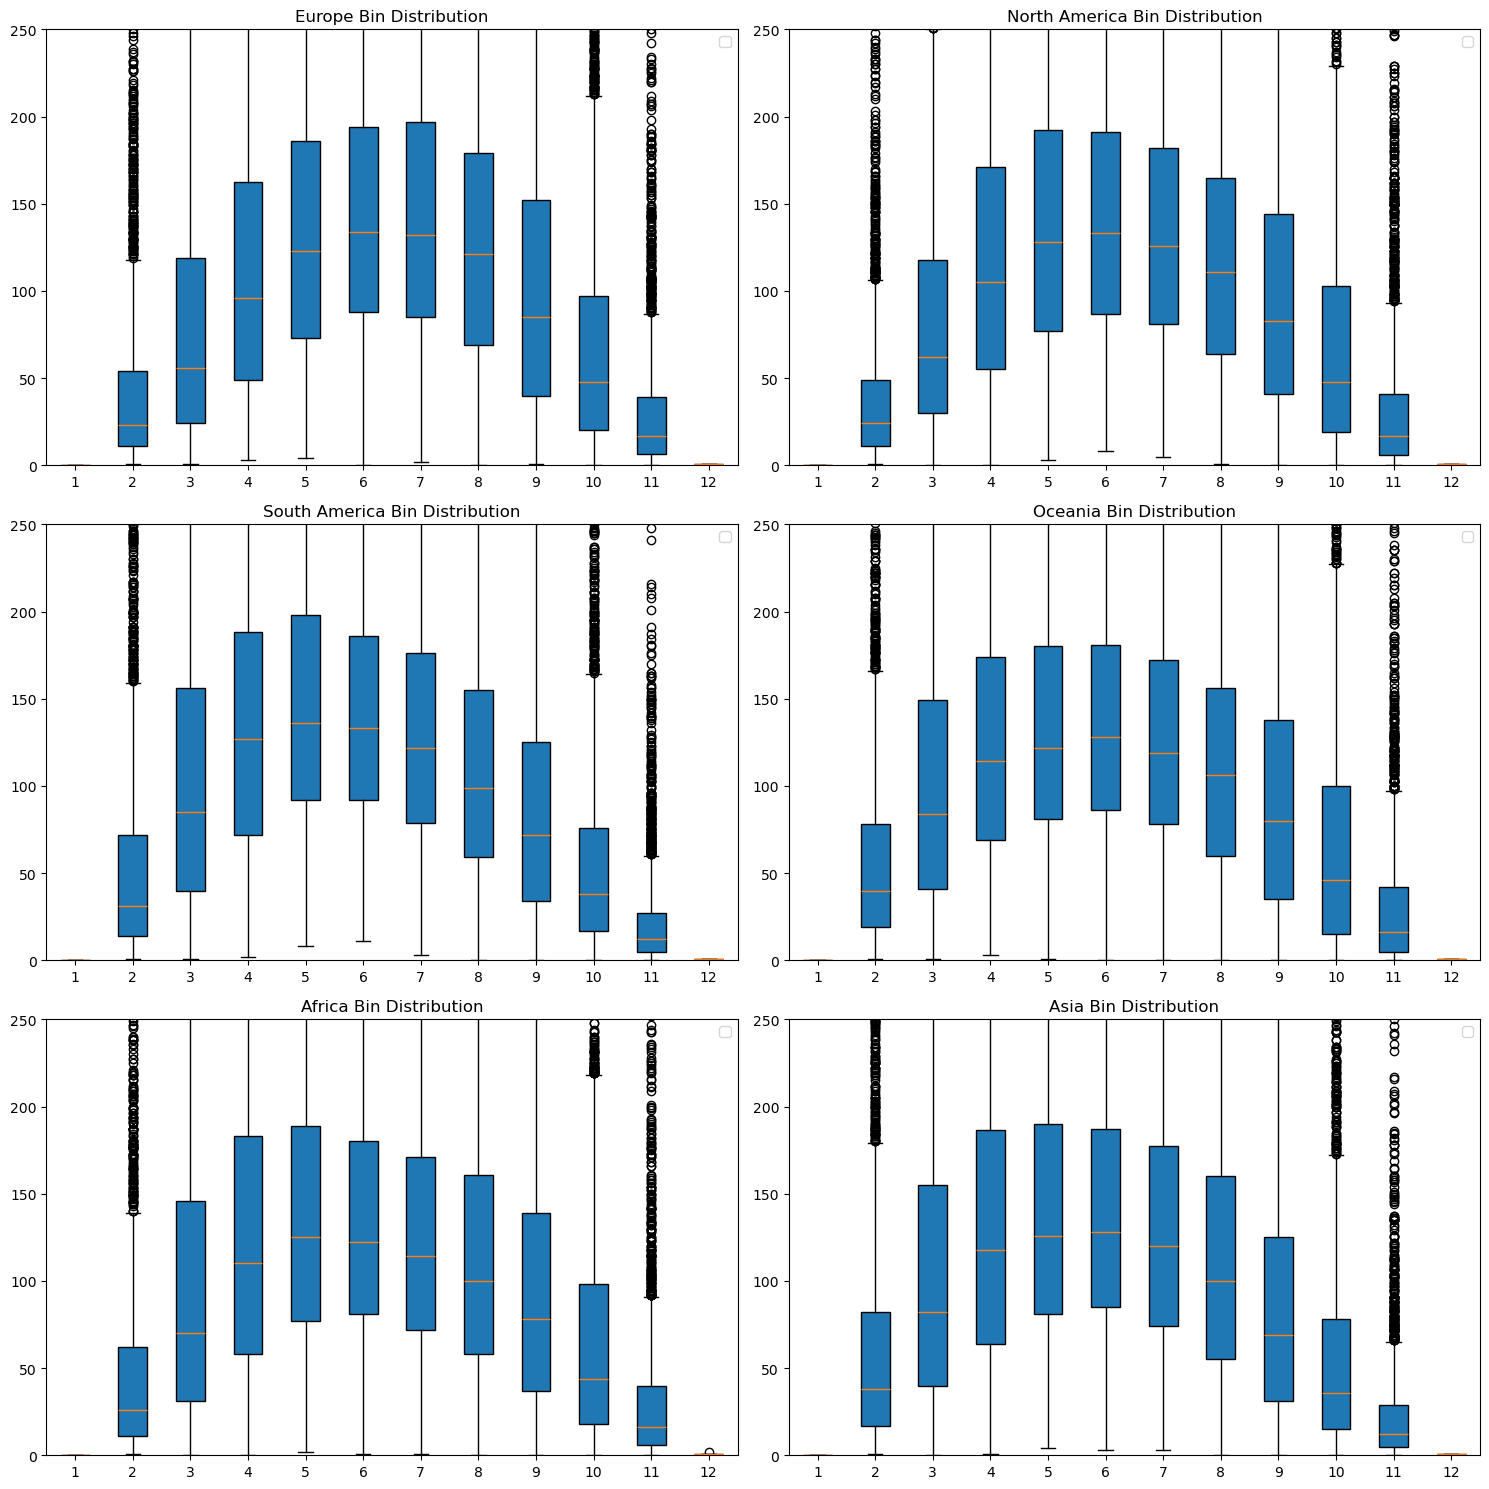

In [75]:
import json

fig, axs = plt.subplots(3, 2, figsize=(15, 15))
regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

with open('region_bins.json', 'r') as f:
    region_bins = json.load(f)

for ax, (region_name, bins_list) in zip(axs.flatten(), region_bins.items()):
    ax.boxplot(np.asarray(bins_list), patch_artist=True)
    ax.set_ylim(0, 250)
    ax.set_title(f'{region_name} Bin Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

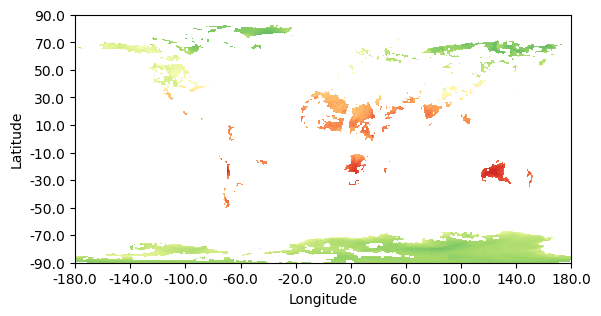

In [4]:
file = nc.Dataset('../RDS/earthdata/MOD11C1_061-20241106_171429/MOD11C1.A2016001.061.2022002121119.hdf', 'r')
temp_data = file['LST_Day_CMG'][:]
plt.imshow(temp_data, cmap=RdYlGn_r)
# Convert row and column indices to latitude and longitude
nrows, ncols = temp_data.shape
plt.xticks(np.linspace(0, ncols, 10), labels=np.round(np.linspace(-180, 180, 10), 2))
plt.yticks(np.linspace(0, nrows, 10), labels=np.round(np.linspace(90, -90, 10), 2))
# plt.colorbar()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [12]:
latitudes

array([ 90.        ,  89.94998611,  89.89997221, ..., -89.89997221,
       -89.94998611, -90.        ])

In [ ]:
def gridify_than_normalize(data):
    sub_arrays_binned = []
    # data = np.asarray(data)
    for i in range(0, data.shape[0], 32):
        for j in range(0, data.shape[1], 32):
            sub_array = data[i:i+32, j:j+32]
            if sub_array[~sub_array.mask].size > 0:
                norm_sub_array = normalize_array(sub_array[~sub_array.mask])
                bin_samples = bin_values(norm_sub_array)
                bin_count = np.bincount(bin_samples)
                sub_arrays_binned.append(bin_count)
    return sub_arrays_binned

gridified_data = gridify_than_normalize(temp_data)
filtered_gridified_data = [item for item in gridified_data if len(item) == 12]
plt.figure(figsize=(10, 5))
plt.boxplot(np.asarray(filtered_gridified_data)[:, 1:11], patch_artist=True)
# plt.set_ylim(0, 250)
# plt.set_title('Bin Distribution')
plt.legend()


In [ ]:
np.asarray(filtered_gridified_data)[:, 1:11]

(9445, 10)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


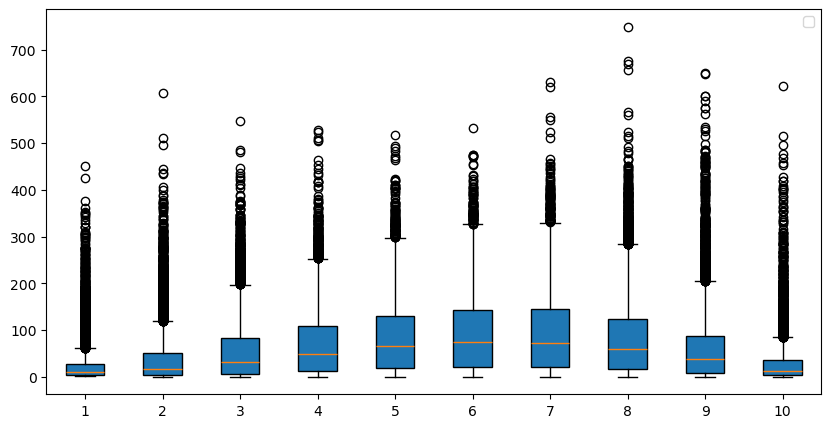

In [70]:
filtered_gridified_data = [item for item in gridified_data if len(item) == 12]
plt.figure(figsize=(10, 5))
plt.boxplot(np.asarray(filtered_gridified_data)[:, 1:11], patch_artist=True)
# plt.set_ylim(0, 250)
# plt.set_title('Bin Distribution')
plt.legend()


In [ ]:
latitudes = np.linspace(90, -90, nrows)
longitudes = np.linspace(-180, 180, ncols)
# Sample random 32*32 window between lat [-70, 70] and lon [-180, 180] and only consider values where mask is false
# sample = sample_within_coordinates(temp_data, [-180, -70, 180, 70], longitudes, latitudes)

# Normalize window
norm_sample = normalize_array(sample[~sample.mask])
# Bin values
bin_sample = bin_values(norm_sample[~norm_sample.mask])
np.bincount(bin_sample)
# Plot histogram

array([ 0, 23, 24, 39, 17, 27, 29, 55, 55, 21,  1,  1])